# 01 · Análisis exploratorio de datos (EDA)

Fase 2 de CRISP-DM: comprensión de los datos. Todo el análisis se hace **solo sobre el train limpio** (40.690 filas, sin las filas que estaban repetidas en test). El hold-out no se mira para no sesgar decisiones.

La lógica está en `src/bank_captacion/eda.py`; este notebook la ejecuta y comenta los resultados.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display, Markdown
from bank_captacion import config as cfg
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

def show(fig):
    display(Image(filename=str(cfg.FIGURES_DIR / fig)))

def table(name, **kw):
    df = pd.read_csv(cfg.TABLES_DIR / name, **kw)
    display(df)
    return df


In [2]:
from bank_captacion.eda import run_eda
key = run_eda()
print(json.dumps(key, indent=2, default=float))

{
  "target": {
    "n_train": 40690,
    "n_pos": 4768,
    "pos_rate": 0.11717866797739002
  },
  "pdays": {
    "pct_pdays_minus1": 81.71295158515606,
    "pdays_minus1_and_previous0": 33249,
    "pdays_minus1_total": 33249,
    "pdays_minus1_poutcome_unknown": 33249,
    "contacted_before_poutcome_unknown": 5,
    "conv_never_contacted": 0.09164185389034257,
    "conv_contacted_before": 0.231286117457331,
    "conv_poutcome_success": 0.6476121562952243
  },
  "month": {
    "spearman_volume_vs_rate": [
      -0.8391608391608393,
      0.0006428259886278203
    ],
    "top_rate_months": {
      "mar": {
        "n": 428,
        "conversion_rate": 0.5304
      },
      "sep": {
        "n": 527,
        "conversion_rate": 0.4782
      },
      "dec": {
        "n": 194,
        "conversion_rate": 0.4691
      },
      "oct": {
        "n": 658,
        "conversion_rate": 0.4347
      }
    },
    "may_share_pct": 30.39567461292701,
    "may_rate": 0.06727037516170763
  },
  "outlier

## 1. Preparación previa del dataset (Fase 0)

Antes del EDA se verificó el esquema y se eliminó el solapamiento train/test. La tabla siguiente es el registro completo de pasos aplicados a las filas.

In [3]:
table('data_preparation_steps.csv')
table('data_summary.csv')

,order,step,dataset,rows_before,rows_after,rows_removed,reason
0,1,load,train,45211,45211,0,banca_train.csv leído con sep=';' y encoding A...
1,2,load,test,4521,4521,0,banca_test.csv leído con sep=';' y encoding AS...
2,3,check_exact_duplicates,train,45211,45211,0,Duplicados exactos dentro de train: 0. No se e...
3,4,check_exact_duplicates,test,4521,4521,0,Duplicados exactos dentro de test: 0. No se el...
4,5,check_nulls,train+test,49732,49732,0,"Nulos: train=0, test=0. Los faltantes vienen c..."
5,6,remove_train_test_overlap,train,45211,40690,4521,4521 de 4521 filas de test (100.0 %) aparecen ...
6,7,save_processed,train,40690,40690,0,Guardado en data/processed/train_clean.csv (si...
7,8,save_processed,test,4521,4521,0,Guardado en data/processed/test_clean.csv (idé...


,dataset,rows,cols,positives,positive_rate_pct,exact_duplicates,nulls,test_rows_found_in_train
0,train_raw,45211,17,5289,11.70,0,0,4521.0
1,train_clean,40690,17,4768,11.72,0,0,0.0
2,test,4521,17,521,11.52,0,0,NaN


,dataset,rows,cols,positives,positive_rate_pct,exact_duplicates,nulls,test_rows_found_in_train
0,train_raw,45211,17,5289,11.70,0,0,4521.0
1,train_clean,40690,17,4768,11.72,0,0,0.0
2,test,4521,17,521,11.52,0,0,NaN


La partición train/test es **aleatoria**: las filas de test están distribuidas uniformemente a lo largo del archivo (ordenado cronológicamente) y las distribuciones de mes, tipo de contacto, resultado previo y target no difieren (p > 0,05 en todos los tests).

In [4]:
table('split_checks.csv')

,check,statistic,p_value,detail
0,posiciones_test_en_train_vs_uniforme (KS),0.0136,0.3715,"posición media relativa = 0.495 (0,5 si es uni..."
1,distribucion_month_train_vs_test (chi2),10.7070,0.4681,12 niveles
2,distribucion_contact_train_vs_test (chi2),1.2270,0.5414,3 niveles
3,distribucion_poutcome_train_vs_test (chi2),4.6370,0.2004,4 niveles
4,distribucion_y_train_vs_test (chi2),0.1300,0.7186,2 niveles


,check,statistic,p_value,detail
0,posiciones_test_en_train_vs_uniforme (KS),0.0136,0.3715,"posición media relativa = 0.495 (0,5 si es uni..."
1,distribucion_month_train_vs_test (chi2),10.7070,0.4681,12 niveles
2,distribucion_contact_train_vs_test (chi2),1.2270,0.5414,3 niveles
3,distribucion_poutcome_train_vs_test (chi2),4.6370,0.2004,4 niveles
4,distribucion_y_train_vs_test (chi2),0.1300,0.7186,2 niveles


## 2. Variable objetivo

Desbalance moderado: 11,7 % de conversiones. Un clasificador trivial que responde siempre "no" tendría 88,3 % de accuracy, por eso accuracy no se usa.

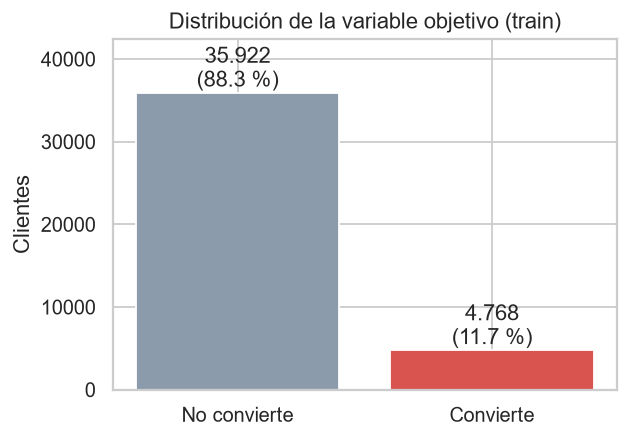

In [5]:
show('eda_target_balance.png')

## 3. Variables numéricas

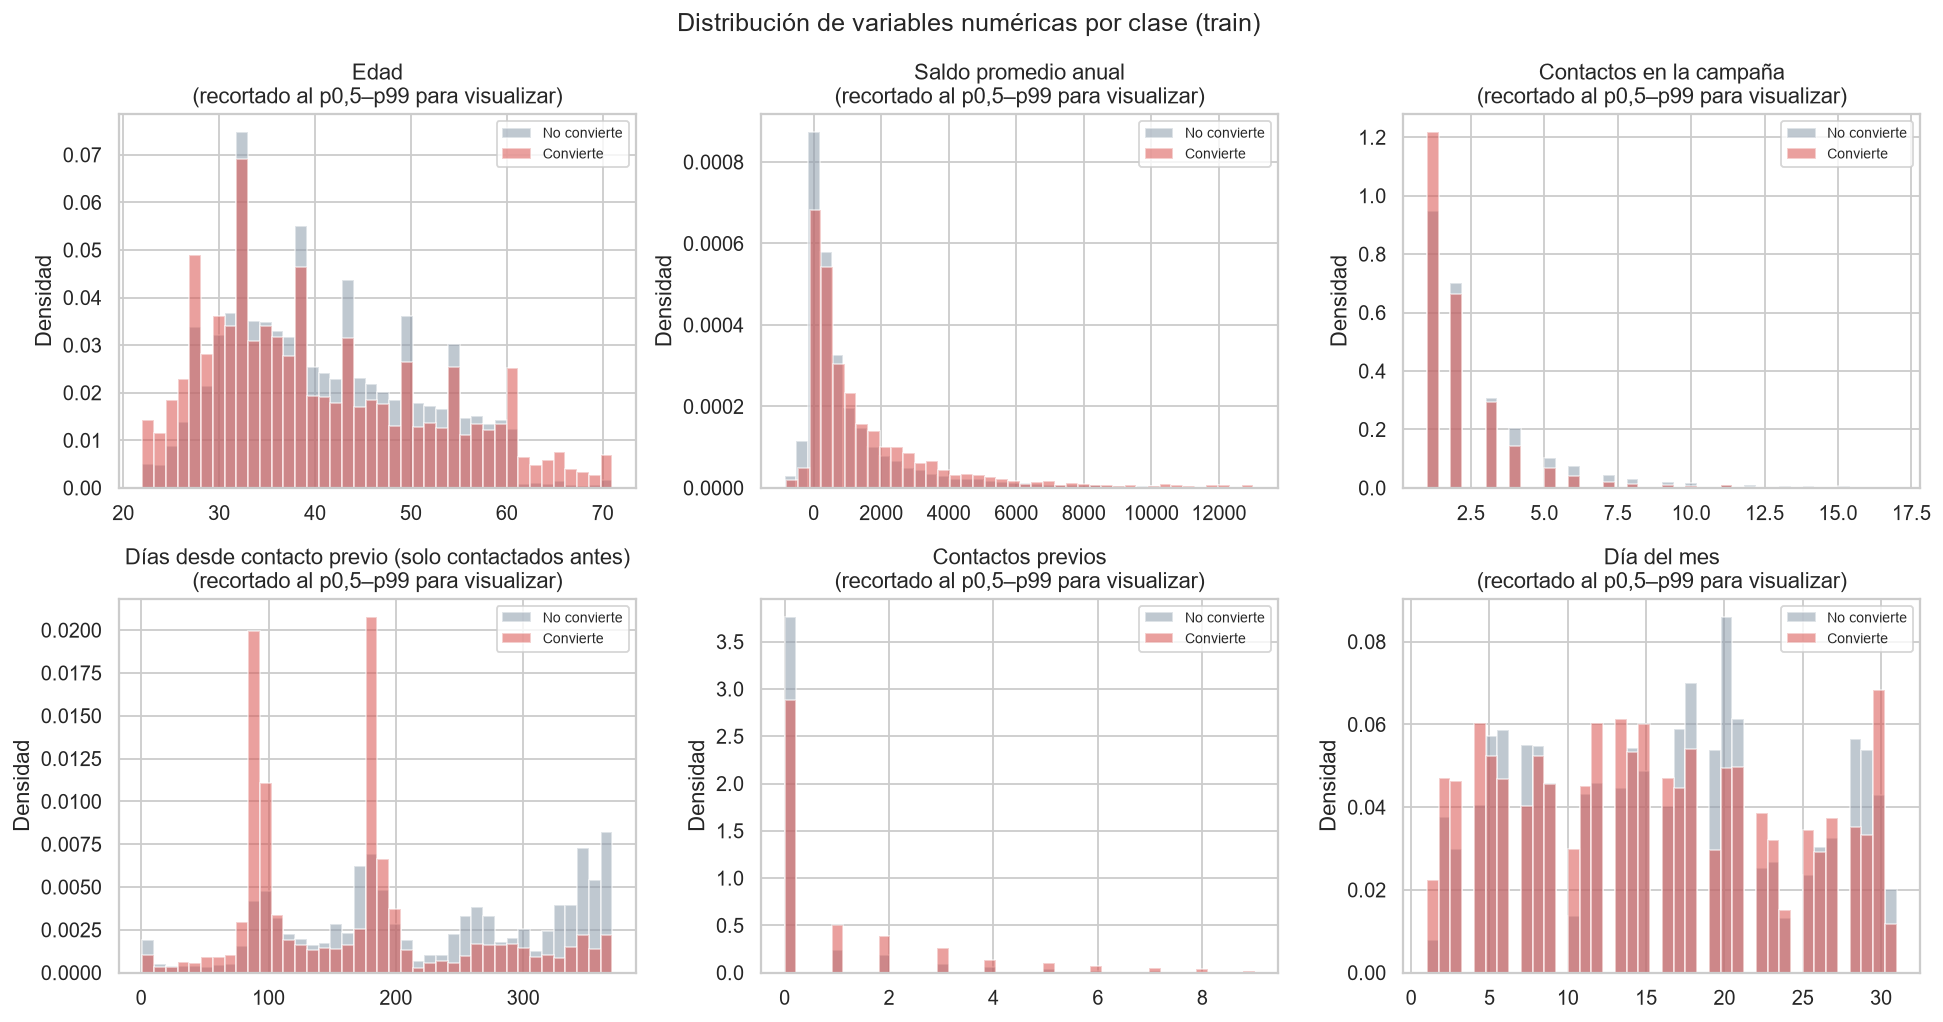

,variable,y,n,mean,std,min,p25,median,p75,p99,max
0,age,no,35922,40.82,10.17,18,33.0,39.0,48.00,66.00,95
1,age,yes,4768,41.58,13.54,18,31.0,38.0,50.00,80.00,95
2,balance,no,35922,1292.64,2962.56,-8019,58.0,417.0,1342.00,12976.01,102127
3,balance,yes,4768,1829.65,3597.10,-3058,215.0,734.0,2156.75,13853.89,81204
4,day,no,35922,15.89,8.30,1,8.0,16.0,21.00,31.00,31
5,day,yes,4768,15.10,8.53,1,8.0,15.0,22.00,30.00,31
6,duration,no,35922,220.61,207.05,0,95.0,163.5,278.00,1014.00,4918
7,duration,yes,4768,535.61,392.77,8,242.0,423.5,720.00,1806.00,3881
8,campaign,no,35922,2.84,3.21,1,1.0,2.0,3.00,17.00,63
9,campaign,yes,4768,2.13,1.90,1,1.0,2.0,2.00,10.00,32


,variable,y,n,mean,std,min,p25,median,p75,p99,max
0,age,no,35922,40.82,10.17,18,33.0,39.0,48.00,66.00,95
1,age,yes,4768,41.58,13.54,18,31.0,38.0,50.00,80.00,95
2,balance,no,35922,1292.64,2962.56,-8019,58.0,417.0,1342.00,12976.01,102127
3,balance,yes,4768,1829.65,3597.10,-3058,215.0,734.0,2156.75,13853.89,81204
4,day,no,35922,15.89,8.30,1,8.0,16.0,21.00,31.00,31
5,day,yes,4768,15.10,8.53,1,8.0,15.0,22.00,30.00,31
6,duration,no,35922,220.61,207.05,0,95.0,163.5,278.00,1014.00,4918
7,duration,yes,4768,535.61,392.77,8,242.0,423.5,720.00,1806.00,3881
8,campaign,no,35922,2.84,3.21,1,1.0,2.0,3.00,17.00,63
9,campaign,yes,4768,2.13,1.90,1,1.0,2.0,2.00,10.00,32


In [6]:
show('eda_numeric_distributions.png')
table('eda_numeric_by_class.csv')

- **Edad**: los que convierten están sobrerrepresentados en los extremos (< 30 y > 60 años: estudiantes y jubilados). Relación no lineal → justifica `age_group` además de `age`.
- **Saldo**: muy asimétrico (asimetría ≈ 8,5), con negativos y ceros. Los que convierten tienen saldos algo mayores.
- **Contactos en la campaña**: más contactos se asocian a menor conversión (insistir no ayuda).
- **pdays**: entre los contactados antes, picos en ~90 y ~180 días con alta conversión (probablemente seguimientos trimestrales/semestrales).

## 4. Variables categóricas: tasa de conversión por categoría

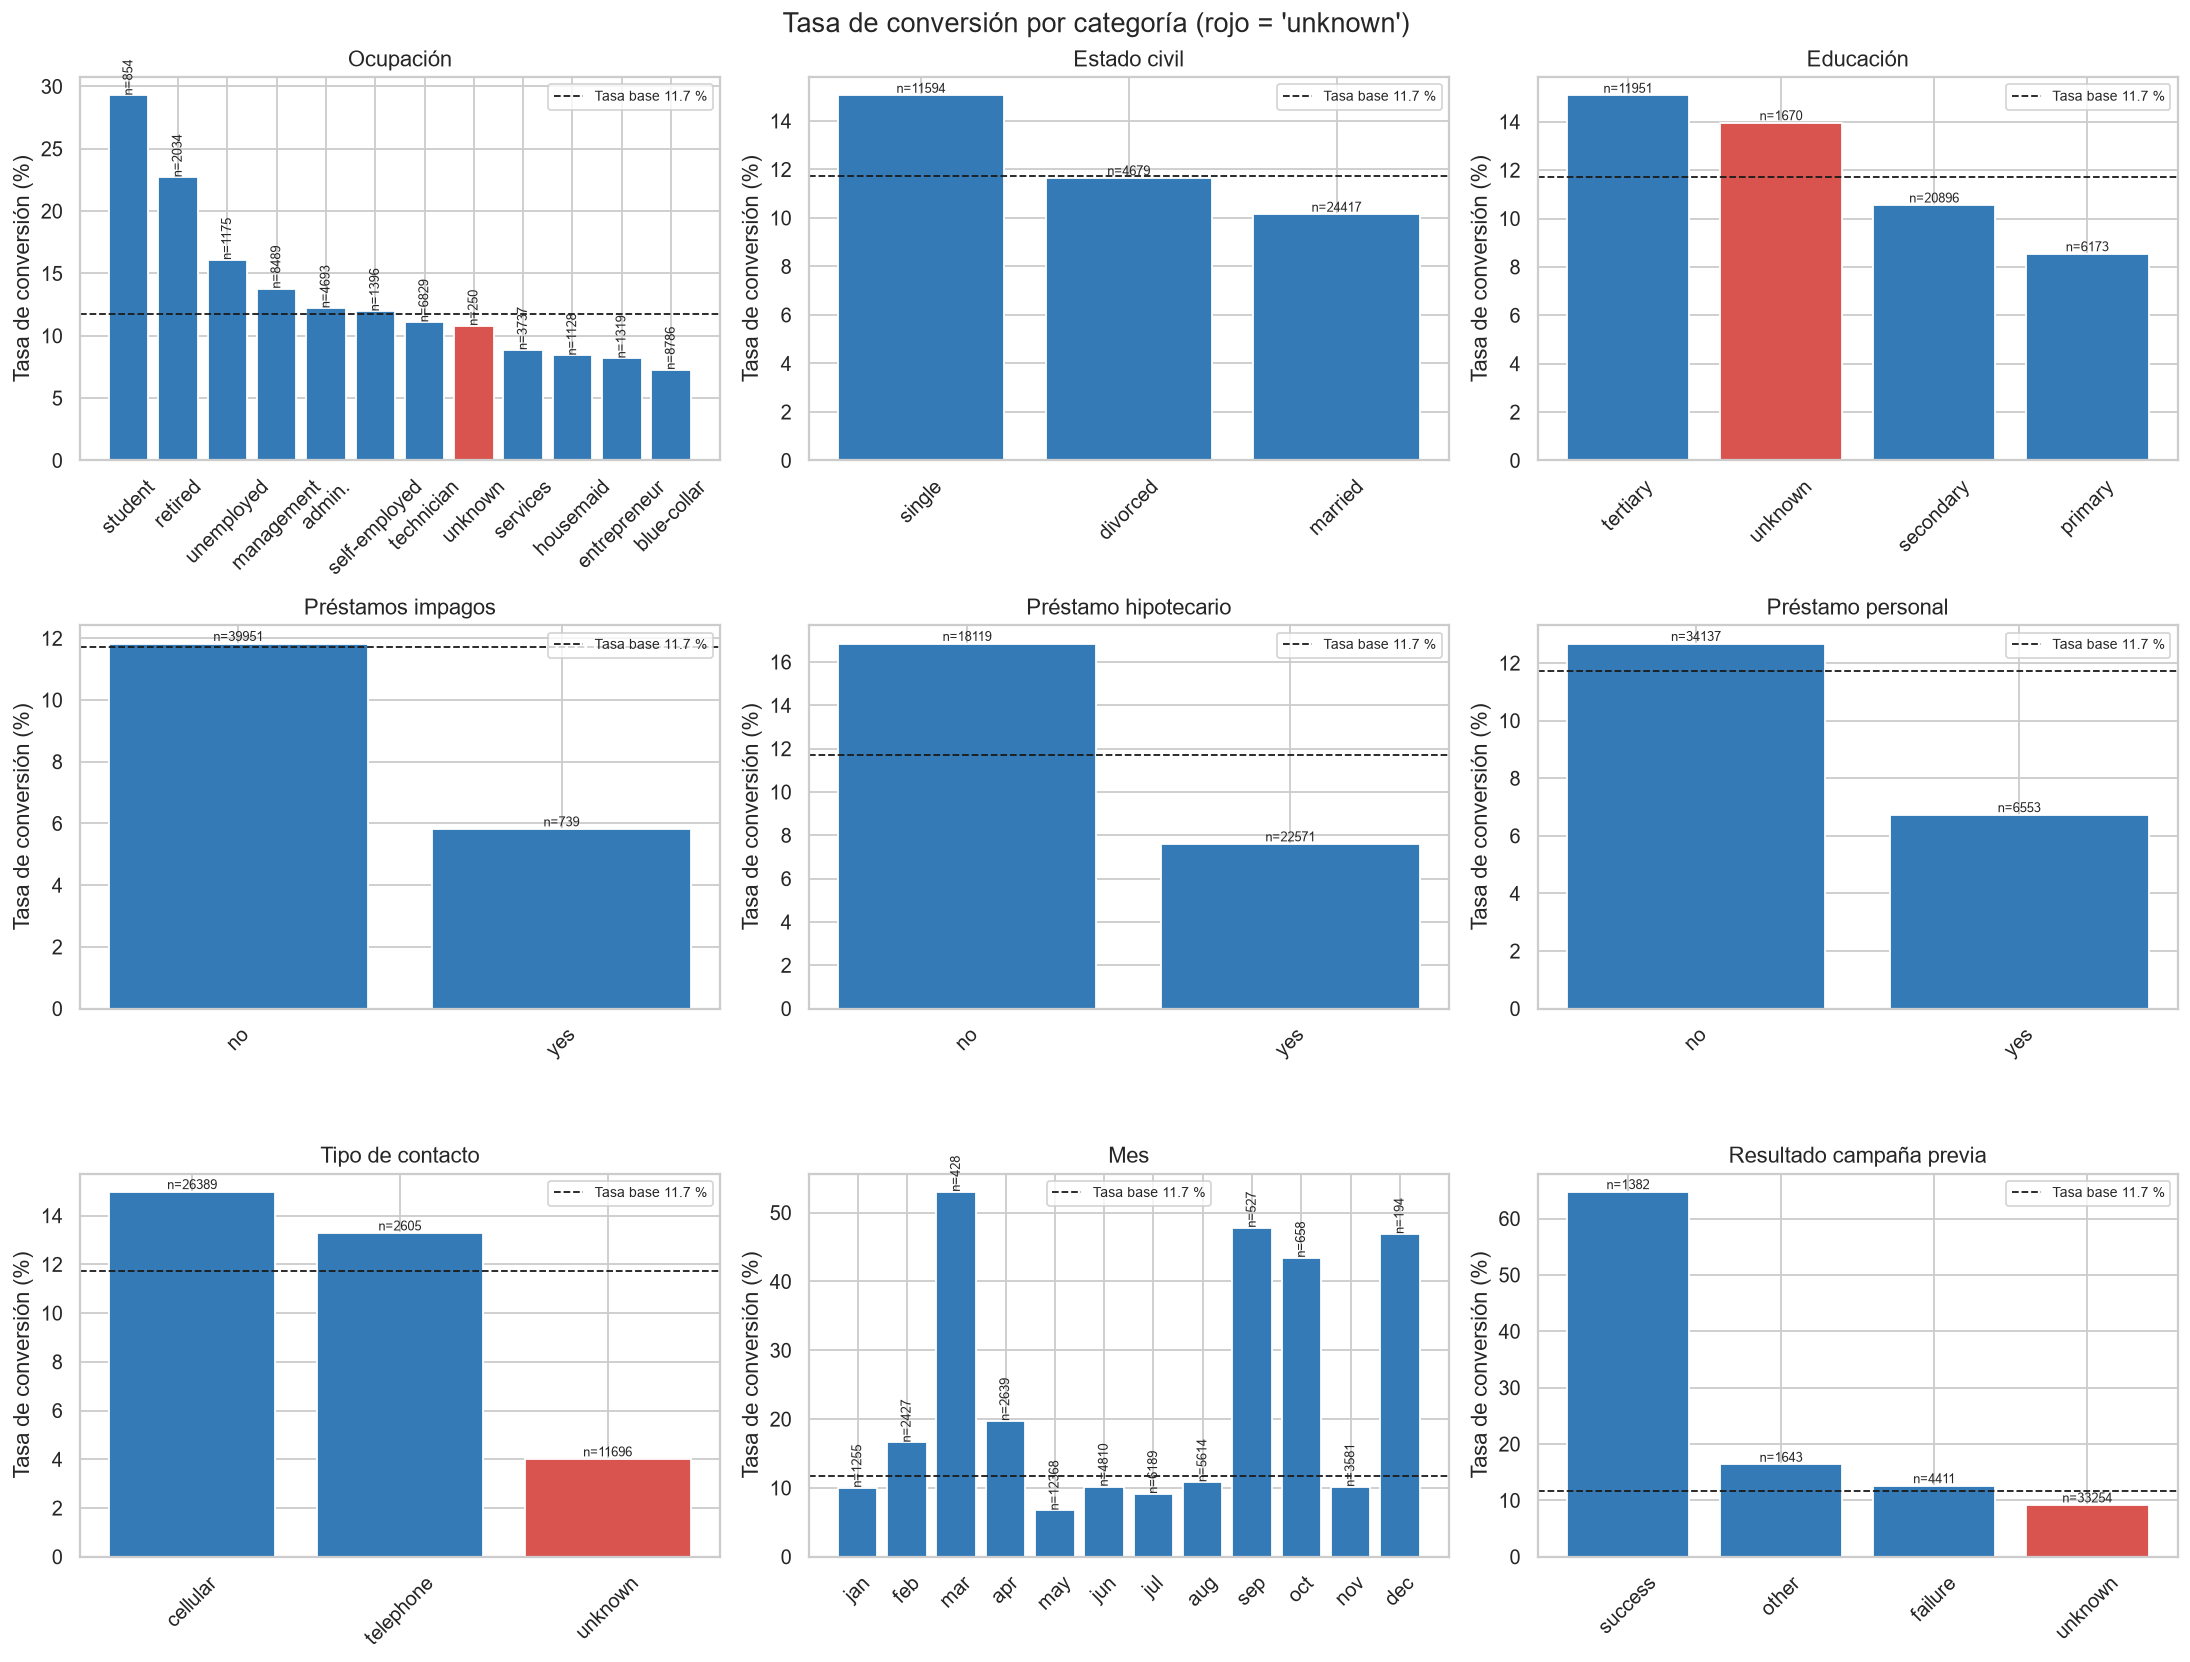

,variable,category,n,conversions,conversion_rate,share,lift_vs_base
0,job,admin.,4693,573,0.1221,0.1153,1.0420
1,job,blue-collar,8786,639,0.0727,0.2159,0.6207
2,job,entrepreneur,1319,108,0.0819,0.0324,0.6988
3,job,housemaid,1128,95,0.0842,0.0277,0.7187
4,job,management,8489,1170,0.1378,0.2086,1.1762
5,job,retired,2034,462,0.2271,0.0500,1.9384
6,job,self-employed,1396,167,0.1196,0.0343,1.0209
7,job,services,3737,331,0.0886,0.0918,0.7559
8,job,student,854,250,0.2927,0.0210,2.4982
9,job,technician,6829,757,0.1109,0.1678,0.9460


In [7]:
show('eda_conversion_by_category.png')
conv = table('eda_conversion_by_category.csv')

- **poutcome = success**: 64,8 % de conversión (5,5 veces la base). Es la señal más fuerte disponible antes de llamar.
- **Ocupación**: estudiantes (29 %) y jubilados (23 %) convierten mucho más que blue-collar (7 %).
- **Préstamos**: tener hipoteca o préstamo personal reduce la conversión casi a la mitad.
- **contact = unknown**: solo 4 % de conversión (ver sección 5).

## 5. `unknown` como categoría con significado propio

,variable,is_unknown,n,conversion_rate
0,job,False,40440,0.1172
1,job,True,250,0.1080
2,education,False,39020,0.1162
3,education,True,1670,0.1395
4,contact,False,28994,0.1483
5,contact,True,11696,0.0401
6,poutcome,False,7436,0.2312
7,poutcome,True,33254,0.0917


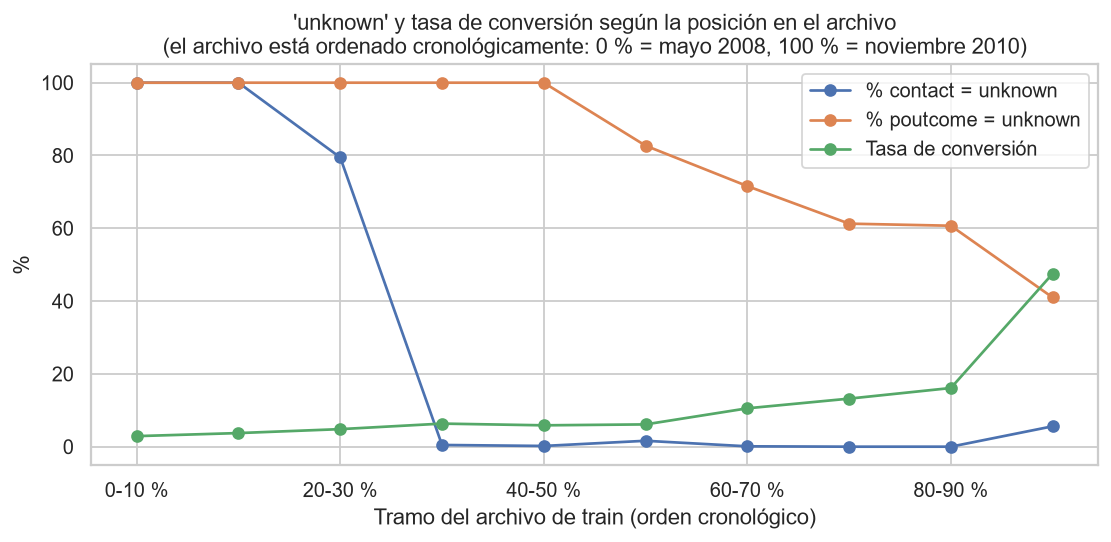

,tramo,pct_contact_unknown,pct_poutcome_unknown,conversion_rate
0,0-10 %,100.00,100.00,2.90
1,10-20 %,100.00,100.00,3.74
2,20-30 %,79.45,100.00,4.82
3,30-40 %,0.47,100.00,6.34
4,40-50 %,0.20,100.00,5.87
5,50-60 %,1.62,82.70,6.12
6,60-70 %,0.10,71.59,10.54
7,70-80 %,0.00,61.27,13.20
8,80-90 %,0.00,60.70,16.12
9,90-100 %,5.60,40.99,47.53


,tramo,pct_contact_unknown,pct_poutcome_unknown,conversion_rate
0,0-10 %,100.00,100.00,2.90
1,10-20 %,100.00,100.00,3.74
2,20-30 %,79.45,100.00,4.82
3,30-40 %,0.47,100.00,6.34
4,40-50 %,0.20,100.00,5.87
5,50-60 %,1.62,82.70,6.12
6,60-70 %,0.10,71.59,10.54
7,70-80 %,0.00,61.27,13.20
8,80-90 %,0.00,60.70,16.12
9,90-100 %,5.60,40.99,47.53


In [8]:
table('eda_unknown_analysis.csv')
show('eda_unknown_by_file_position.png')
table('eda_unknown_by_file_position.csv')

`unknown` **no es un faltante aleatorio**:

- `contact = unknown` ocupa el 100 % del primer 20 % del archivo y desaparece después del 30 %: corresponde a un período (mayo–junio 2008) en que no se registraba el canal. Su baja conversión (4 %) refleja ese período, no el canal.
- `poutcome = unknown` = cliente nunca contactado en una campaña previa (ver sección 6).
- La tasa de conversión crece a lo largo del archivo (de 2,9 % a 47,5 %): **hay drift temporal** fuerte en los datos. Con una partición aleatoria esto no afecta la evaluación, pero es una limitación para producción.

Decisión: mantener `unknown` como categoría propia (no imputar a la moda).

## 6. `pdays = -1`, `previous` y `poutcome`

,pdays_eq_-1,previous_eq_0,failure,other,success,unknown,All
0,False,False,4411,1643,1382,5,7441
1,True,True,0,0,0,33249,33249
2,All,NaN,4411,1643,1382,33254,40690


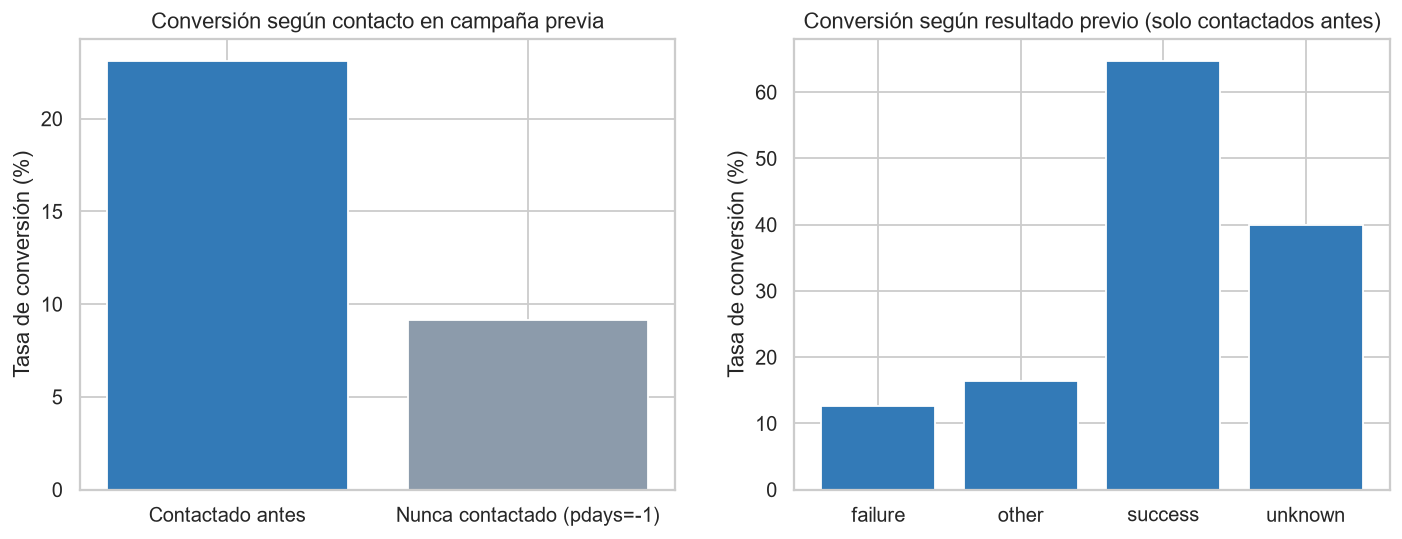

In [9]:
table('eda_pdays_previous_poutcome.csv')
show('eda_pdays_poutcome.png')

Las tres variables codifican lo mismo cuando el cliente nunca fue contactado: las 33.249 filas con `pdays = -1` tienen `previous = 0` y `poutcome = unknown`. Solo 5 filas tienen contacto previo pero `poutcome = unknown` (inconsistencia menor, se conservan). El -1 **no es un número**: tratarlo como tal le diría a un modelo lineal que "-1 días" está cerca de "0 días". Por eso en la Fase 3 se crea la bandera `previously_contacted` y `pdays_clean` (NaN cuando -1).

## 7. `month`: estacionalidad aparente vs volumen

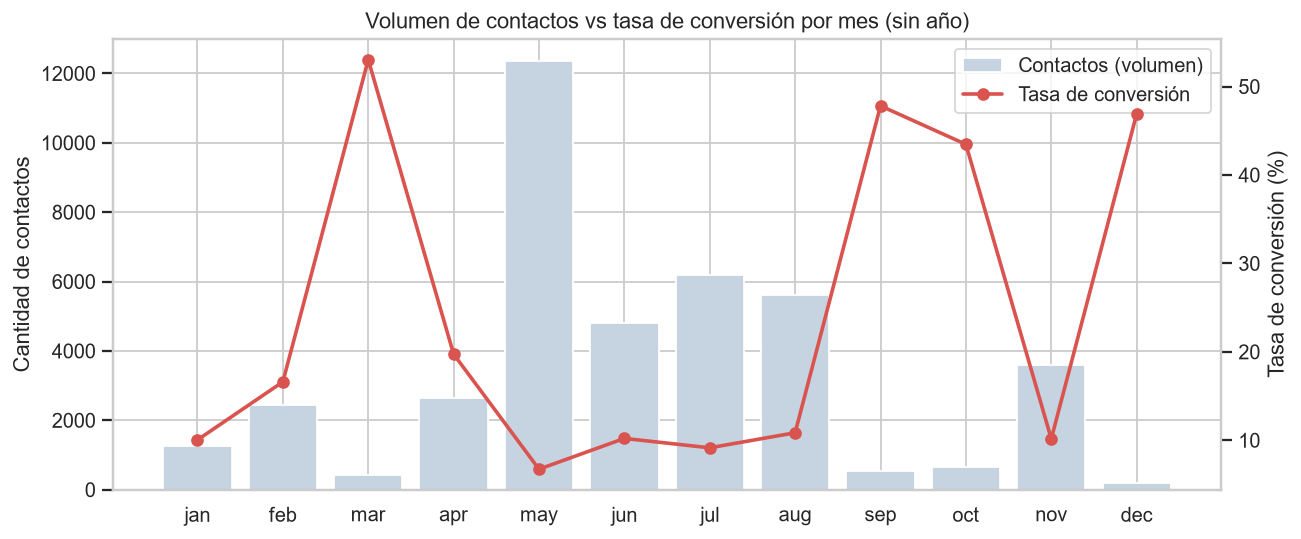

,month,n,conversions,conversion_rate,share_pct
0,jan,1255,126,0.1004,3.0843
1,feb,2427,403,0.1660,5.9646
2,mar,428,227,0.5304,1.0519
3,apr,2639,521,0.1974,6.4856
4,may,12368,832,0.0673,30.3957
5,jun,4810,491,0.1021,11.8211
6,jul,6189,566,0.0915,15.2101
7,aug,5614,609,0.1085,13.7970
8,sep,527,252,0.4782,1.2952
9,oct,658,286,0.4347,1.6171


,month,n,conversions,conversion_rate,share_pct
0,jan,1255,126,0.1004,3.0843
1,feb,2427,403,0.1660,5.9646
2,mar,428,227,0.5304,1.0519
3,apr,2639,521,0.1974,6.4856
4,may,12368,832,0.0673,30.3957
5,jun,4810,491,0.1021,11.8211
6,jul,6189,566,0.0915,15.2101
7,aug,5614,609,0.1085,13.7970
8,sep,527,252,0.4782,1.2952
9,oct,658,286,0.4347,1.6171


In [10]:
show('eda_month_volume_rate.png')
table('eda_month_volume_rate.csv')

Mayo concentra el 30 % de los contactos con la menor tasa (6,7 %), mientras que marzo, septiembre, octubre y diciembre tienen tasas del 43–53 % con muy poco volumen (1–2 % cada uno). La correlación de Spearman entre volumen y tasa es −0,84 (p < 0,001).

Interpretación: no es estacionalidad del cliente sino de **la operación**: los meses con campañas masivas tienen tasas bajas y los meses con pocas llamadas (dirigidas, o del final del período 2010) tienen tasas altas. Como el dataset no trae el año, `month` actúa en parte como proxy del período. Se usa como variable (se conoce antes de llamar), pero se advierte que su efecto puede no trasladarse a campañas futuras.

## 8. Outliers: `balance` y `campaign`

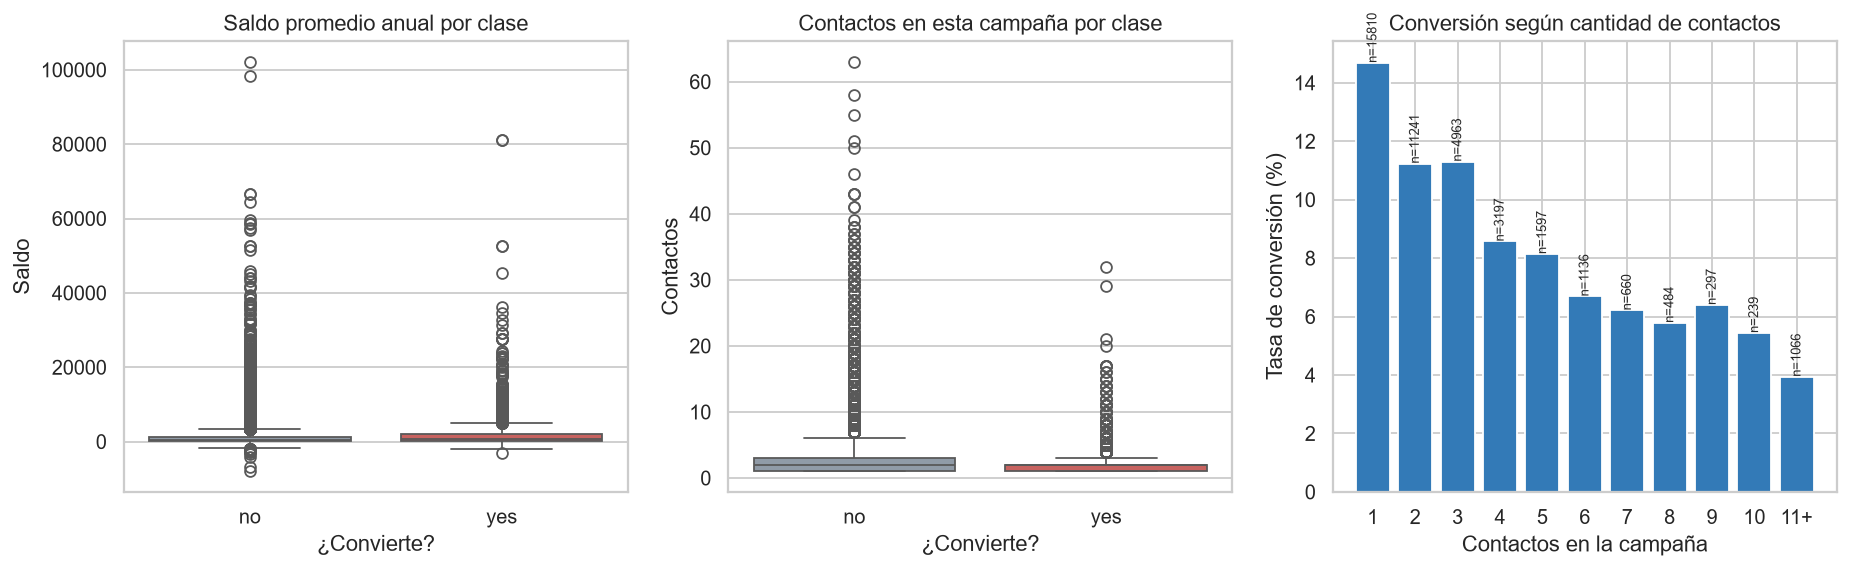

{
  "balance_p99": 13054.0,
  "balance_max": 102127,
  "balance_min": -8019,
  "balance_pct_negative": 8.355861391005162,
  "balance_pct_zero": 7.758663062177439,
  "balance_pct_outliers_iqr": 10.361268124846399,
  "balance_skew": 8.549625159203488,
  "campaign_p99": 17.0,
  "campaign_max": 63,
  "campaign_pct_above_p99": 0.8503317768493488,
  "conv_campaign_1": 0.1468058191018343,
  "conv_campaign_ge_5": 0.06369775506479285
}


In [11]:
show('eda_outliers_balance_campaign.png')
print(json.dumps(key['outliers'], indent=2))

- `balance`: 10,4 % de outliers por la regla IQR, valores entre −8.019 y 102.127. No son errores (saldos altos existen), por eso **no se eliminan**: se aplica transformación logarítmica con signo y se agregan banderas de saldo negativo (8,4 %) y cero (7,8 %).
- `campaign`: máximo 63 contactos, p99 = 17. La conversión cae de 14,7 % (1 contacto) a 6,4 % (≥ 5). Se **winsoriza al p99** (calculado dentro de cada fold) para que valores extremos no dominen los modelos lineales.

## 9. `duration`: por qué es leakage

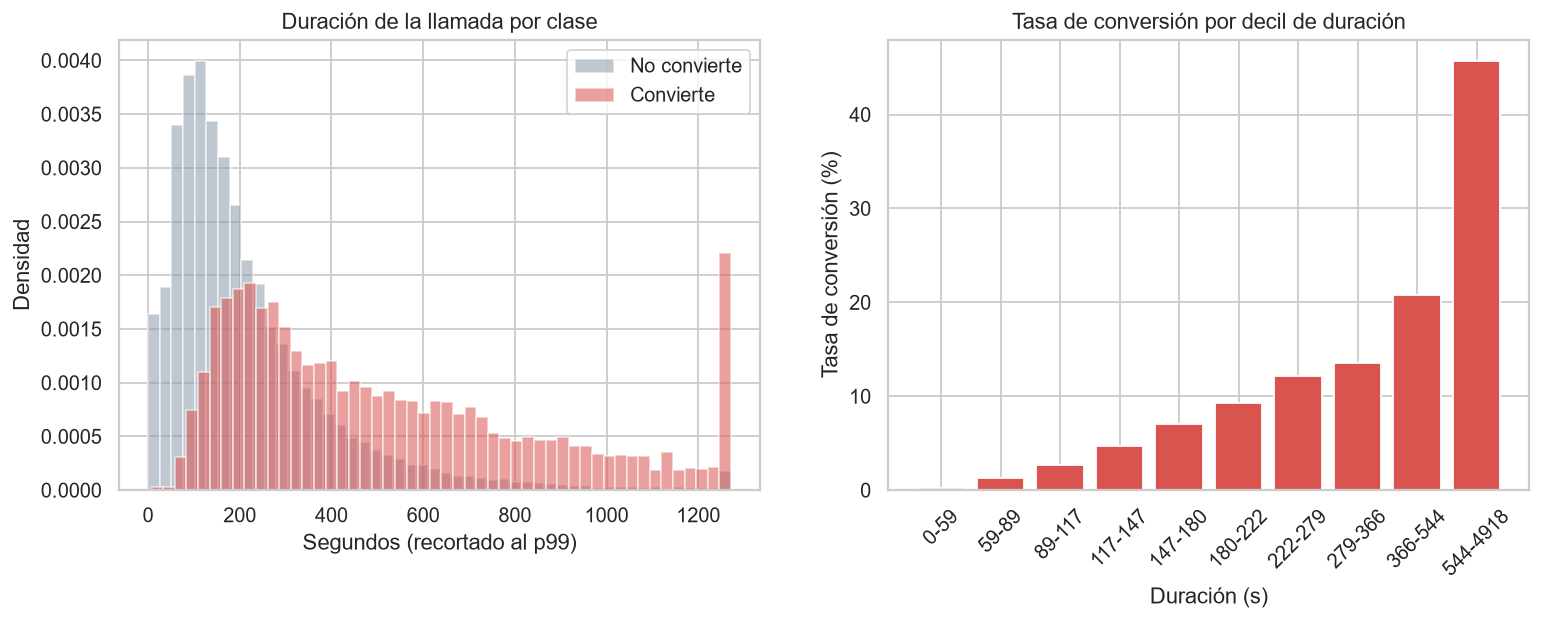

{
  "duration_zero_n": 3,
  "duration_zero_conv": 0.0,
  "duration_median_no": 163.5,
  "duration_median_yes": 423.5,
  "duration_auc_alone": 0.8068397734847949,
  "conv_duration_top_decile": 0.45687530803351406,
  "conv_duration_bottom_decile": 0.00191433357262503,
  "pct_short_calls_lt_60s": 10.270336692061932,
  "conv_short_calls_lt_60s": 0.00191433357262503
}


In [12]:
show('eda_duration_leakage.png')
print(json.dumps(key['duration'], indent=2))

`duration` por sí sola tiene ROC-AUC ≈ 0,81: más que muchos modelos completos sin ella. La mediana de duración es 164 s en los que no convierten y 424 s en los que convierten; las llamadas de menos de 60 s casi nunca convierten (0,2 %). Solo hay 3 llamadas con duración 0.

El problema: **la duración se conoce recién al terminar la llamada**, y una llamada larga es en buena medida *consecuencia* del interés del cliente. Un modelo que la use no puede decidir a quién llamar. Se excluye del modelo entregable y se usa solo para cuantificar el efecto (Fase 5).

## 10. Ranking preliminar de variables

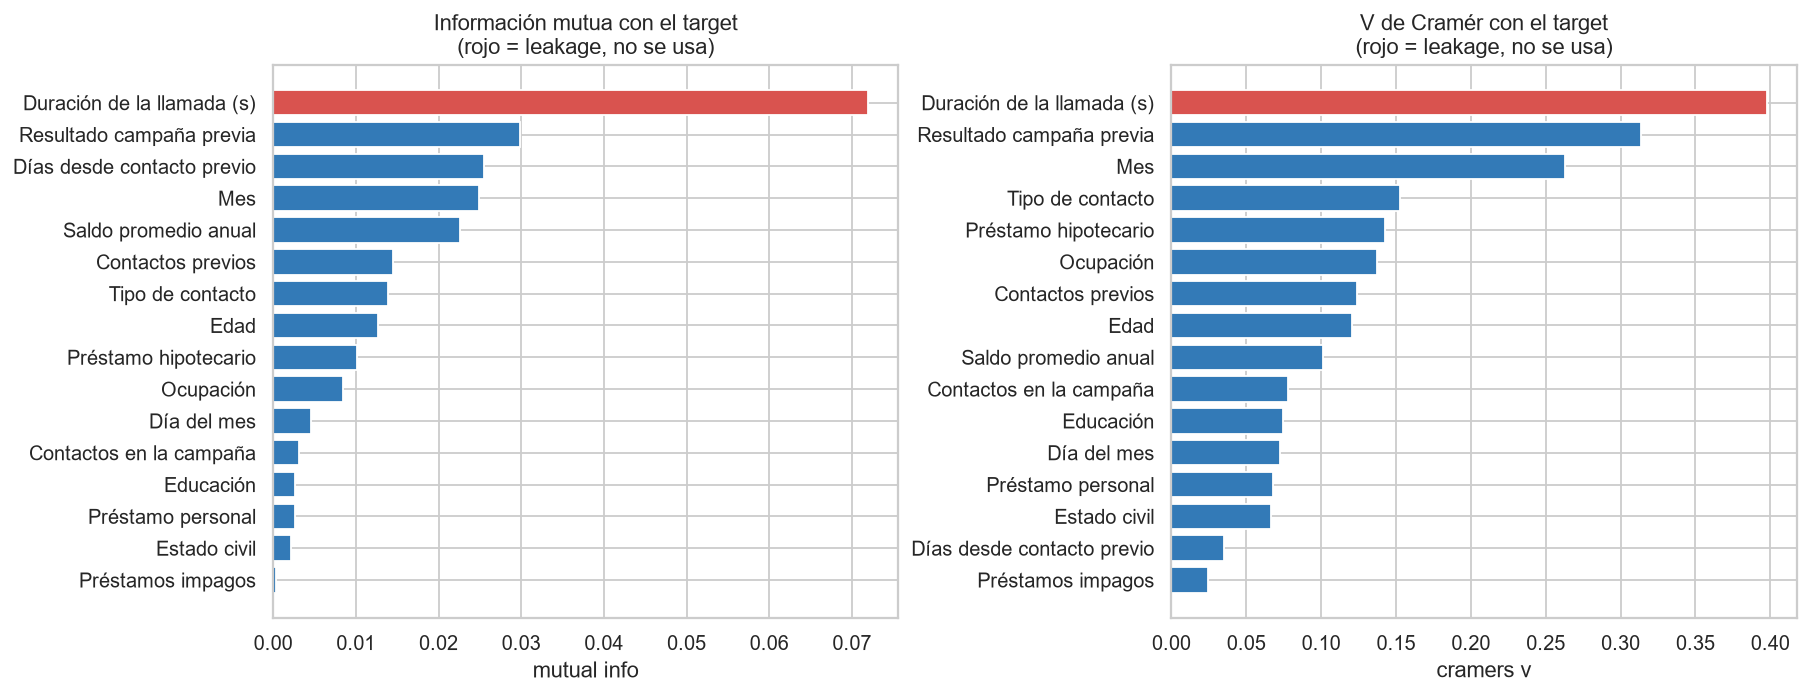

,variable,type,cramers_v,mutual_info,is_leakage
0,duration,numérica,0.3976,0.0720,True
1,poutcome,categórica,0.3136,0.0298,False
2,pdays,numérica,0.0350,0.0255,False
3,month,categórica,0.2631,0.0249,False
4,balance,numérica,0.1014,0.0226,False
5,previous,numérica,0.1238,0.0145,False
6,contact,categórica,0.1526,0.0139,False
7,age,numérica,0.1205,0.0127,False
8,housing,categórica,0.1429,0.0102,False
9,job,categórica,0.1373,0.0085,False


,variable,type,cramers_v,mutual_info,is_leakage
0,duration,numérica,0.3976,0.0720,True
1,poutcome,categórica,0.3136,0.0298,False
2,pdays,numérica,0.0350,0.0255,False
3,month,categórica,0.2631,0.0249,False
4,balance,numérica,0.1014,0.0226,False
5,previous,numérica,0.1238,0.0145,False
6,contact,categórica,0.1526,0.0139,False
7,age,numérica,0.1205,0.0127,False
8,housing,categórica,0.1429,0.0102,False
9,job,categórica,0.1373,0.0085,False


In [13]:
show('eda_feature_ranking.png')
table('eda_feature_ranking.csv')

Sin contar `duration`, las variables más informativas son `poutcome`, `pdays`, `month`, `balance`, `previous`, `contact`, `age` y `housing`. `default` es prácticamente no informativa (V ≈ 0,02). Nota: la V de Cramér de `pdays` es baja porque el 82 % de sus valores es −1 y al discretizar en deciles queda casi en un único grupo; la información mutua sí la detecta.

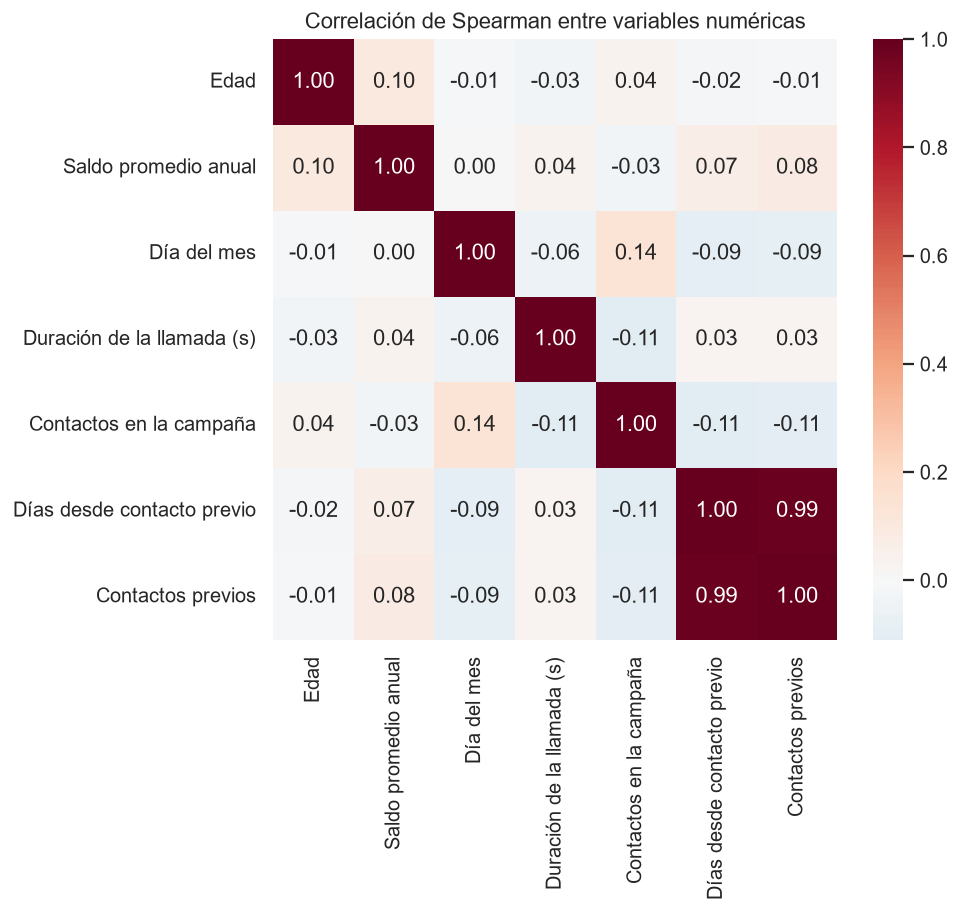

In [14]:
show('eda_numeric_correlation.png')

Correlaciones bajas entre numéricas, salvo `pdays`–`previous` (misma información de contacto previo). No hay multicolinealidad severa que obligue a descartar variables.